## Simulação Empírica (Monte Carlo) e Estatísticas

Embora a multiplicação de matrizes nos dê as probabilidades exatas, sistemas reais transitam de um estado discreto para outro. Podemos simular essa trajetória utilizando geração de números aleatórios baseada nas probabilidades da matriz de transição (Método de Monte Carlo).

Abaixo, criamos uma função para simular $N$ rodadas e extraímos três estatísticas visuais importantes:
1. **Histograma dos Estados:** Frequência absoluta de visitas a cada estado.
2. **Matriz de Transição Empírica (Heatmap):** A matriz reconstruída a partir das contagens reais da simulação (para comparar com a matriz teórica).
3. **Evolução dos Estados:** A proporção acumulada de cada estado ao longo do tempo.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# ==========================================
# SIMULAÇÃO EMPÍRICA DE PASSOS
# ==========================================

def simular_markov(matriz_transicao, estado_inicial, n_rodadas):
    n_estados = matriz_transicao.shape[0]
    caminho = [estado_inicial]
    estado_atual = estado_inicial
    # Estado inicial: 100% de certeza que começa em estado inicial
    pi_atual = np.zeros(matriz_transicao.shape[0])# crio o vetor de estados incial com todas as probabilidades = 0
    pi_atual[estado_inicial] = 1 # Define probabilidade inicial do estado incial = 100%
    
    
    for _ in range(n_rodadas):
        # Sorteia o próximo estado com base nas probabilidades da linha atual
        proximo_estado = np.random.choice(n_estados, p=matriz_transicao[estado_atual])
        #print(estado_atual)
        caminho.append(proximo_estado)
        estado_atual = proximo_estado
        pi_atual = np.dot(pi_atual, matriz_transicao) #Faz o ajuste da probabilidade de cada estado
        
    return np.array(caminho), pi_atual

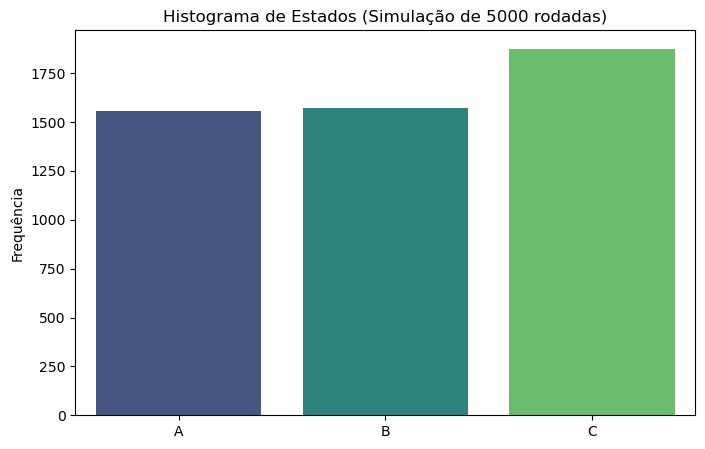

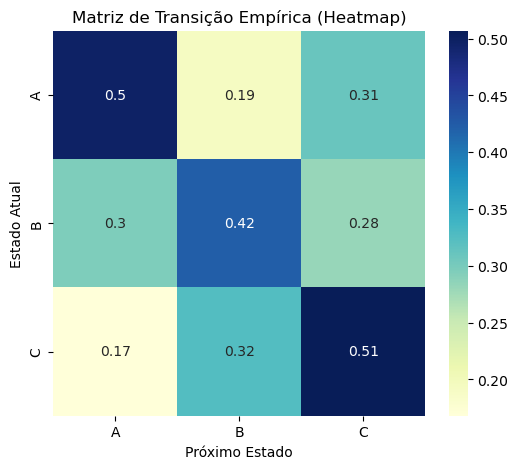

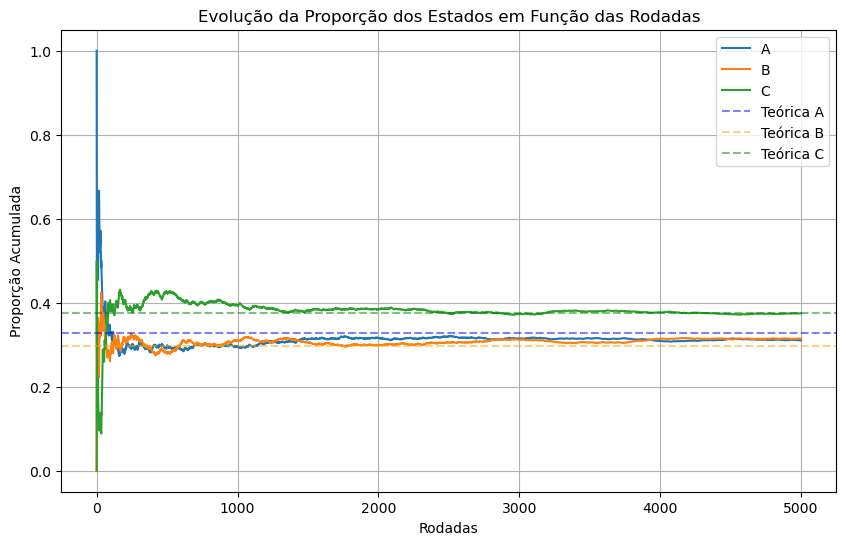

In [26]:
# Simulando 5000 rodadas

# Matriz de Transição Teórica (3x3)
# As linhas devem somar 1.
P_teorica = np.array([
    [0.5, 0.2, 0.3], # De Baixa para: Baixa, Neutro, Alta
    [0.3, 0.4, 0.3], # De Neutro para: Baixa, Neutro, Alta
    [0.2, 0.3, 0.5]  # De Alta para: Baixa, Neutro, Alta
])

# Estado inicial: 100% de certeza que começa em 'Neutro'


estados = ['A', 'B', 'C']

# Estado inicial: 100% de certeza que começa em 'Neutro'

caminho_simulado, pi_atual = simular_markov(P_teorica, estado_inicial=0, n_rodadas=5000)

# --- Gráfico 1: Histograma de Estados ---
plt.figure(figsize=(8, 5))
sns.countplot(x=[estados[i] for i in caminho_simulado], order=estados, palette="viridis")
plt.title("Histograma de Estados (Simulação de 5000 rodadas)")
plt.ylabel("Frequência")
plt.show()

# --- Gráfico 2: Heatmap da Matriz de Transição Empírica ---
matriz_empirica = np.zeros_like(P_teorica)
for i in range(len(caminho_simulado)-1):
    estado_origem = caminho_simulado[i]
    estado_destino = caminho_simulado[i+1]
    matriz_empirica[estado_origem, estado_destino] += 1

# Normalizando as linhas para obter probabilidades
matriz_empirica = matriz_empirica / matriz_empirica.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_empirica, annot=True, cmap="YlGnBu", xticklabels=estados, yticklabels=estados)
plt.title("Matriz de Transição Empírica (Heatmap)")
plt.ylabel("Estado Atual")
plt.xlabel("Próximo Estado")
plt.show()

# --- Gráfico 3: Evolução das Proporções (Convergência Empírica) ---
# Calcula a proporção acumulada de cada estado ao longo das rodadas
ev_A = np.cumsum(caminho_simulado == 0) / np.arange(1, len(caminho_simulado) + 1)
ev_B = np.cumsum(caminho_simulado == 1) / np.arange(1, len(caminho_simulado) + 1)
ev_C = np.cumsum(caminho_simulado == 2) / np.arange(1, len(caminho_simulado) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ev_A, label='A')
plt.plot(ev_B, label='B')
plt.plot(ev_C, label='C')

plt.axhline(y=pi_atual[0], color='blue', linestyle='--', alpha=0.5, label='Teórica A')
plt.axhline(y=pi_atual[1], color='orange', linestyle='--', alpha=0.5, label='Teórica B')
plt.axhline(y=pi_atual[2], color='green', linestyle='--', alpha=0.5, label='Teórica C')

plt.title("Evolução da Proporção dos Estados em Função das Rodadas")
plt.xlabel("Rodadas")
plt.ylabel("Proporção Acumulada")
plt.grid()
plt.legend()
plt.show()

# Exercício

## Usando a função simular_markov adapte o script anterior para uma Matriz de transição 4 x 4 onde os estados são A, B, C e D

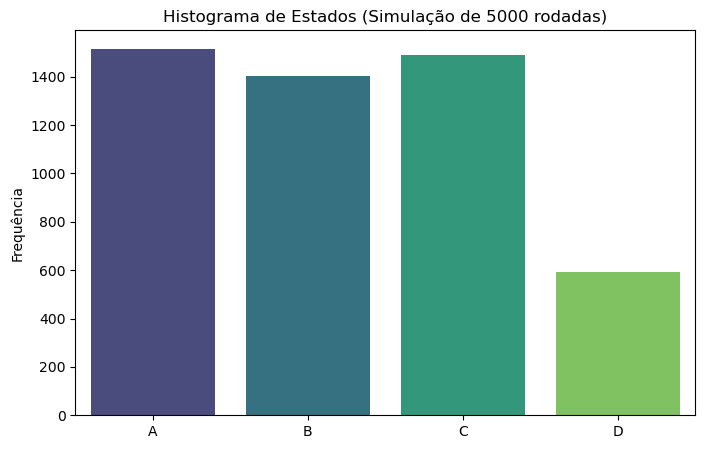

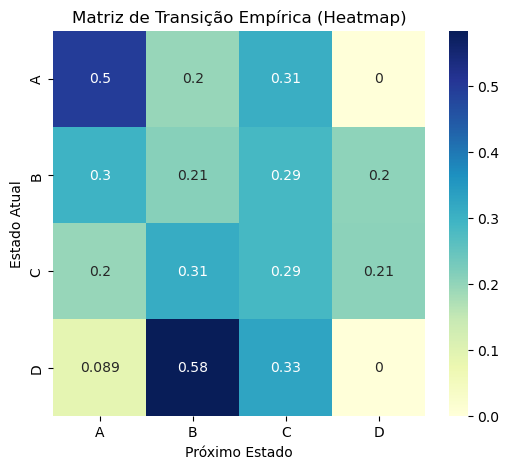

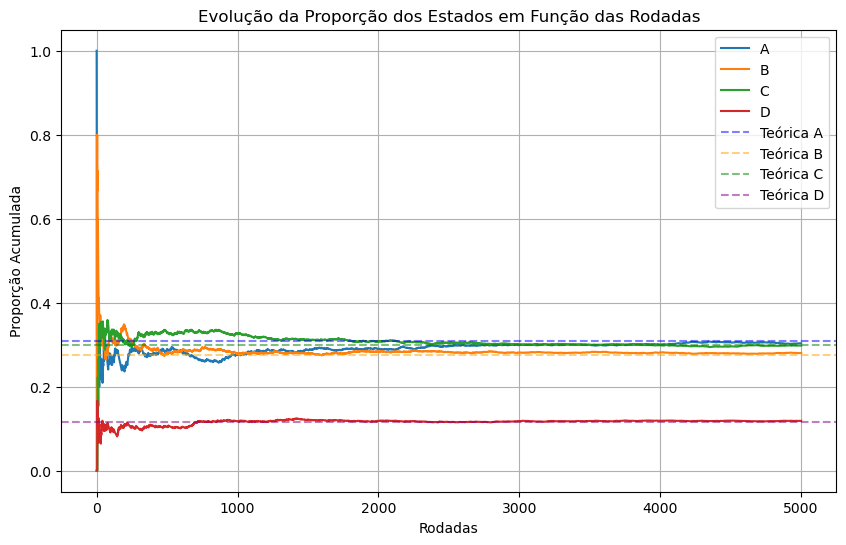

In [29]:
# Simulando 5000 rodadas

# Criando uma Matriz de Transição Teórica (4x4)
# As linhas devem somar 1.
P_teorica = np.array([
    [0.5, 0.2, 0.3, 0.0], # De A para: A, B, C, D
    [0.3, 0.2, 0.3, 0.2], # De B para: A, B, C, D
    [0.2, 0.3, 0.3, 0.2 ], # De C para: A, B, C, D
    [0.1, 0.6, 0.3, 0.0 ] # De D para: A, B, C, D
])

# Estado inicial: 100% de certeza que começa em 'Neutro'


estados = ['A', 'B', 'C', "D"]

# Estado inicial: 100% de certeza que começa em 'Neutro'

caminho_simulado, pi_atual = simular_markov(P_teorica, estado_inicial=0, n_rodadas=5000)

# --- Gráfico 1: Histograma de Estados ---
plt.figure(figsize=(8, 5))
sns.countplot(x=[estados[i] for i in caminho_simulado], order=estados, palette="viridis")
plt.title("Histograma de Estados (Simulação de 5000 rodadas)")
plt.ylabel("Frequência")
plt.show()

# --- Gráfico 2: Heatmap da Matriz de Transição Empírica ---
matriz_empirica = np.zeros_like(P_teorica)
for i in range(len(caminho_simulado)-1):
    estado_origem = caminho_simulado[i]
    estado_destino = caminho_simulado[i+1]
    matriz_empirica[estado_origem, estado_destino] += 1

# Normalizando as linhas para obter probabilidades
matriz_empirica = matriz_empirica / matriz_empirica.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_empirica, annot=True, cmap="YlGnBu", xticklabels=estados, yticklabels=estados)
plt.title("Matriz de Transição Empírica (Heatmap)")
plt.ylabel("Estado Atual")
plt.xlabel("Próximo Estado")
plt.show()

# --- Gráfico 3: Evolução das Proporções (Convergência Empírica) ---
# Calcula a proporção acumulada de cada estado ao longo das rodadas
ev_A = np.cumsum(caminho_simulado == 0) / np.arange(1, len(caminho_simulado) + 1)
ev_B = np.cumsum(caminho_simulado == 1) / np.arange(1, len(caminho_simulado) + 1)
ev_C = np.cumsum(caminho_simulado == 2) / np.arange(1, len(caminho_simulado) + 1)
ev_D = np.cumsum(caminho_simulado == 3) / np.arange(1, len(caminho_simulado) + 1) # Criamos uma nova evolução para o estado D

plt.figure(figsize=(10, 6))
plt.plot(ev_A, label='A')
plt.plot(ev_B, label='B')
plt.plot(ev_C, label='C')
plt.plot(ev_D, label='D')

plt.axhline(y=pi_atual[0], color='blue', linestyle='--', alpha=0.5, label='Teórica A')
plt.axhline(y=pi_atual[1], color='orange', linestyle='--', alpha=0.5, label='Teórica B')
plt.axhline(y=pi_atual[2], color='green', linestyle='--', alpha=0.5, label='Teórica C')
plt.axhline(y=pi_atual[3], color='purple', linestyle='--', alpha=0.5, label='Teórica D')

plt.title("Evolução da Proporção dos Estados em Função das Rodadas")
plt.xlabel("Rodadas")
plt.ylabel("Proporção Acumulada")
plt.grid()
plt.legend()
plt.show()